## **1D Quantum Confinement**

A hard-wall box on 16 grid points (4 qubits): Hamiltonian, ansatz, the three measurement decompositions, and the training loop.

### **Set Problem**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qconflib import problem_1d

n = 4                       # qubits  ->  N = 16 grid points
prob = problem_1d(n)        # u0 = 0: an empty hard-wall box

print(f"{prob.label}   {prob.n} qubits, {2**prob.n} grid points")
print(f"ground-state energy  {prob.lam_min:.6f}")
print(f"first excited        {prob.eigvals[1]:.6f}   (gap {prob.gap01:.6f})")
print(f"\nH is {prob.M.shape[0]}x{prob.M.shape[1]}; the top-left 5x5 block:")
print(np.round(prob.M[:5, :5], 3))

1D box N=16, u0=0.0 eV   4 qubits, 16 grid points
ground-state energy  0.034054
first excited        0.135056   (gap 0.101002)

H is 16x16; the top-left 5x5 block:
[[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]


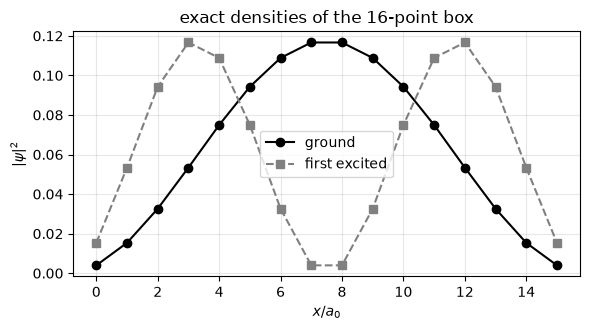

In [2]:
x = np.arange(2**n)
plt.figure(figsize=(6, 3.4))
plt.plot(x, np.abs(prob.ground)**2, 'ko-', label='ground')
plt.plot(x, np.abs(prob.excited1)**2, 's--', color='0.5', label='first excited')
plt.xlabel(r'$x/a_0$'); plt.ylabel(r'$|\psi|^2$'); plt.legend(); plt.grid(alpha=.3)
plt.title('exact densities of the 16-point box'); plt.tight_layout(); plt.show()

### **Design Ansatz**

depth 3 on 4 qubits  ->  12 parameters


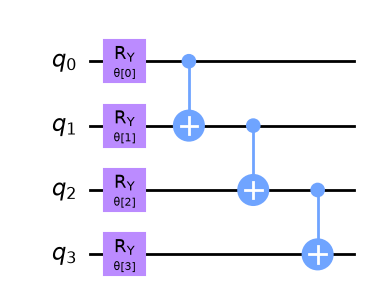

In [3]:
from qiskit.circuit import ParameterVector
from qconflib import make_HEA

depth = 3
P = n * depth
theta = ParameterVector('θ', P)
print(f"depth {depth} on {n} qubits  ->  {P} parameters")

make_HEA(n, 1, ParameterVector('θ', n)).draw('mpl', style='clifford', fold=-1)

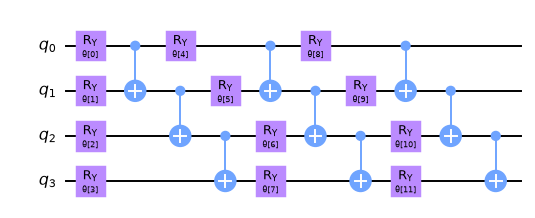

In [4]:
# the full depth-3 ansatz used below
make_HEA(n, depth, theta).draw('mpl', style='clifford', fold=-1, scale=0.7)

### **Measurement Decompositions**

PO and FD use 2 circuits per evaluation, SD uses $n$ shallow ones.

In [5]:
from qconflib import n_circuits, BatchedExpectation


class _Raw:              # executor stand-in: hand the circuit back untouched
    def transpile(self, qc):
        return qc


def measurement_circuits(problem, method, depth=1):
    """The circuits the estimator runs, before transpilation."""
    return BatchedExpectation(problem, method, depth, _Raw()).templates


for m in ('PO', 'SD', 'FD'):
    circs = measurement_circuits(prob, m, depth=1)
    twoq = [sum(1 for i in c.data if i.operation.num_qubits >= 2) for c in circs]
    print(f"{m}: {n_circuits(m, prob)} circuits per <H>, "
          f"multi-qubit gates per circuit {twoq}")

PO: 2 circuits per <H>, multi-qubit gates per circuit [1, 4]
SD: 4 circuits per <H>, multi-qubit gates per circuit [4, 3, 2, 1]
FD: 2 circuits per <H>, multi-qubit gates per circuit [21, 4]


### **PO Circuits**

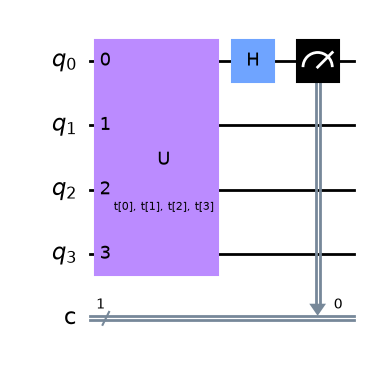

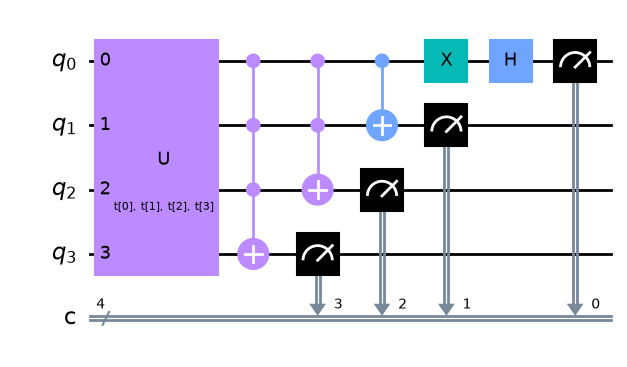

In [6]:
po = measurement_circuits(prob, 'PO', depth=1)
display(po[0].draw('mpl', style='clifford', fold=-1))   # even bonds: one Hadamard on q0
display(po[1].draw('mpl', style='clifford', fold=-1))   # cyclic increment, then Hadamard

### **SD Circuits**

component j = 0


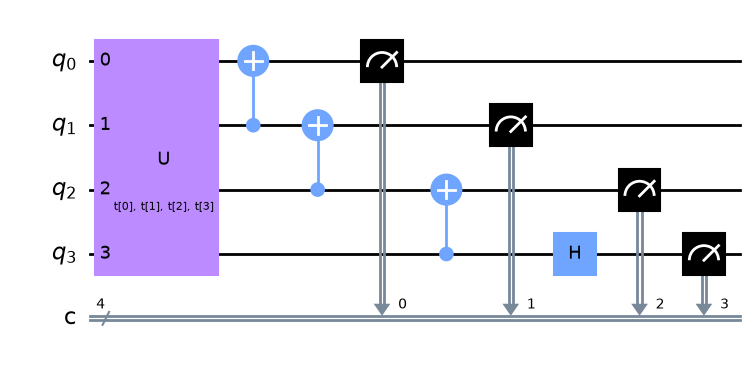

component j = 1


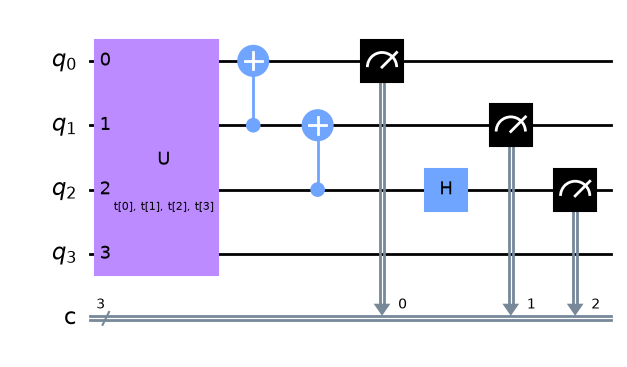

component j = 2


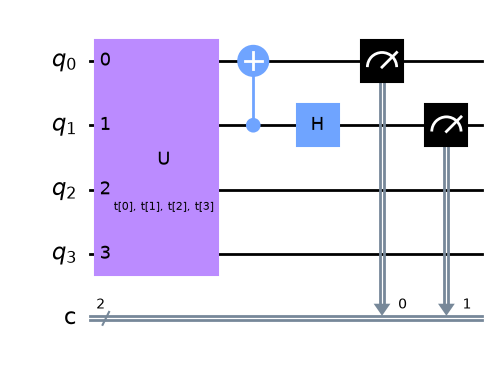

component j = 3


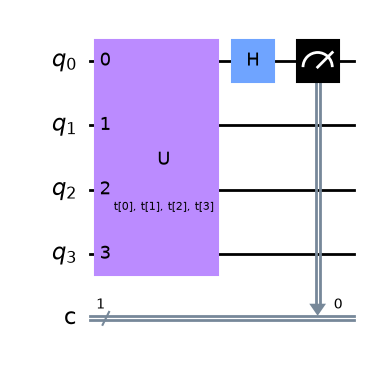

In [7]:
sd = measurement_circuits(prob, 'SD', depth=1)
for j, c in enumerate(sd):
    print(f"component j = {j}")
    display(c.draw('mpl', style='clifford', fold=-1))

### **FD Circuits**

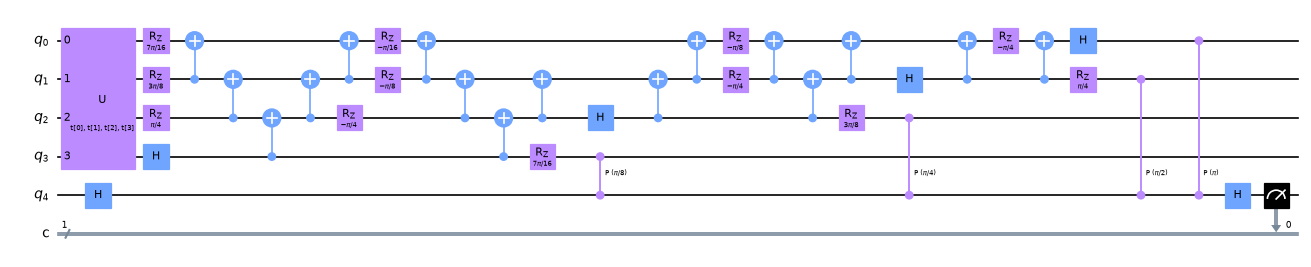

plus the wrap-correction circuit, gate-identical to PO's second circuit:


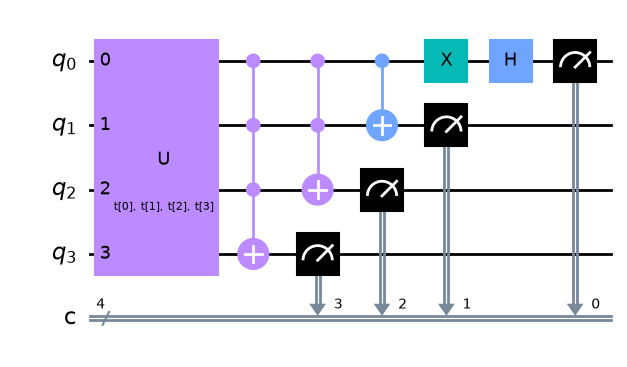

In [8]:
fd = measurement_circuits(prob, 'FD', depth=1)
display(fd[0].draw('mpl', style='clifford', fold=-1, scale=0.6))   # QFT Hadamard test
print("plus the wrap-correction circuit, gate-identical to PO's second circuit:")
display(fd[1].draw('mpl', style='clifford', fold=-1))

### **Validate Estimators**

In [9]:
from qconflib import Executor, BatchedExpectation, statevector

rng = np.random.default_rng(7)
th = rng.uniform(-np.pi, np.pi, P)
psi = statevector(th, n, depth)
exact = float(psi @ prob.M @ psi)

ex = Executor(seed=111)                      # ideal simulator, frozen seed
print(f"exact <H> at this theta: {exact:.5f}\n")
for m in ('PO', 'SD', 'FD'):
    bx = BatchedExpectation(prob, m, depth, ex)
    for shots in (2**12, 2**16, 2**20):
        v = bx.value(th, shots)
        print(f"  {m}  {shots:>8} shots -> {v:.5f}   (error {abs(v-exact):.5f})")
    print()

exact <H> at this theta: 2.44348



  PO      4096 shots -> 2.42212   (error 0.02136)
  PO     65536 shots -> 2.44214   (error 0.00134)


  PO   1048576 shots -> 2.44449   (error 0.00101)

  SD      4096 shots -> 2.45605   (error 0.01258)
  SD     65536 shots -> 2.43796   (error 0.00552)


  SD   1048576 shots -> 2.44429   (error 0.00082)

  FD      4096 shots -> 2.44849   (error 0.00501)
  FD     65536 shots -> 2.45560   (error 0.01212)


  FD   1048576 shots -> 2.44311   (error 0.00037)



### **Train (shot noise only)**

In [10]:
from qconflib import solve
import time

runs = {}
for m in ('SD', 'FD'):
    t0 = time.perf_counter()
    runs[m] = solve(prob, method=m, depth=depth, shots=2**14, seed=111,
                    stages=((150, 2**14),), screen=8)
    print(f"{m}: trace {runs[m]['trace']:.4f}, energy {runs[m]['energy']:.5f} "
          f"(exact {prob.lam_min:.5f})   [{time.perf_counter()-t0:.0f} s]")

SD: trace 0.0174, energy 0.03434 (exact 0.03405)   [12 s]


FD: trace 0.0584, energy 0.03779 (exact 0.03405)   [8 s]


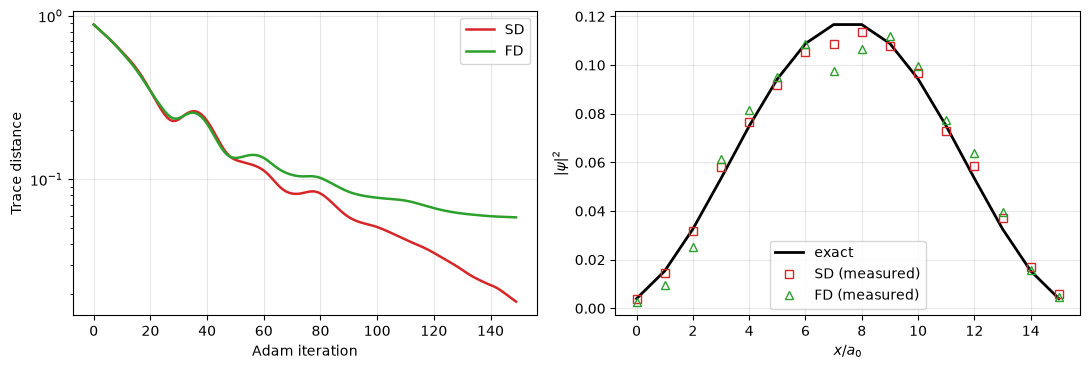

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for m, c in [('SD', '#d62728'), ('FD', '#2ca02c')]:
    tr = [h[2] for h in runs[m]['history']]
    ax[0].semilogy(tr, color=c, lw=1.8, label=m)
ax[0].set_xlabel('Adam iteration'); ax[0].set_ylabel('Trace distance')
ax[0].grid(alpha=.3); ax[0].legend()

ax[1].plot(x, np.abs(prob.ground)**2, 'k-', lw=2, label='exact')
for m, c, mk in [('SD', '#d62728', 's'), ('FD', '#2ca02c', '^')]:
    ax[1].plot(x, runs[m]['rho'], mk, color=c, mfc='none', label=f'{m} (measured)')
ax[1].set_xlabel(r'$x/a_0$'); ax[1].set_ylabel(r'$|\psi|^2$')
ax[1].grid(alpha=.3); ax[1].legend()
plt.tight_layout(); plt.show()

### **COBYLA vs Parameter-Shift Adam**

In [12]:
t0 = time.perf_counter()
cobyla = solve(prob, method='SD', depth=depth, shots=2**14, seed=111,
               optimizer='COBYLA', maxiter=400, screen=8)
print(f"COBYLA: trace {cobyla['trace']:.4f} after {cobyla['evals']} cost evaluations "
      f"[{time.perf_counter()-t0:.0f} s]")
print(f"Adam  : trace {runs['SD']['trace']:.4f} after {len(runs['SD']['history'])} steps "
      f"= {2*P*len(runs['SD']['history'])} cost evaluations")

COBYLA: trace 0.1387 after 140 cost evaluations [21 s]
Adam  : trace 0.0174 after 150 steps = 3600 cost evaluations


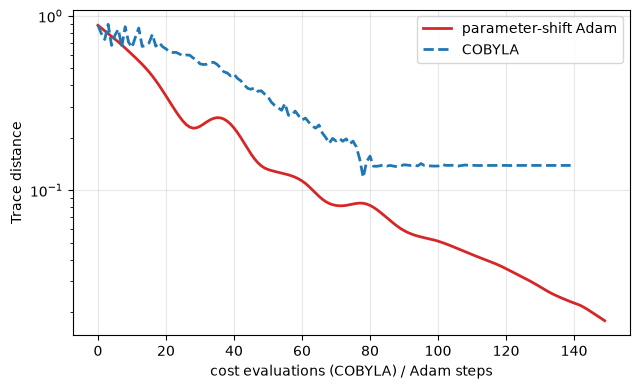

In [13]:
plt.figure(figsize=(6.5, 4))
plt.semilogy([h[2] for h in runs['SD']['history']], color='#d62728', lw=2,
             label='parameter-shift Adam')
plt.semilogy([h[2] for h in cobyla['history']], '--', color='#1f77b4', lw=2, label='COBYLA')
plt.xlabel('cost evaluations (COBYLA) / Adam steps')
plt.ylabel('Trace distance'); plt.grid(alpha=.3); plt.legend()
plt.tight_layout(); plt.show()

### **Add Device Noise**

In [14]:
t0 = time.perf_counter()
noisy = solve(prob, method='SD', depth=depth, shots=2**13, seed=111,
              stages=((80, 2**13),), screen=8, noise_from='sherbrooke')
print(f"SD under FakeSherbrooke gate noise: trace {noisy['trace']:.4f}   "
      f"[{time.perf_counter()-t0:.0f} s]")
print(f"SD with shot noise only            : trace {runs['SD']['trace']:.4f}")

SD under FakeSherbrooke gate noise: trace 0.0906   [42 s]
SD with shot noise only            : trace 0.0174


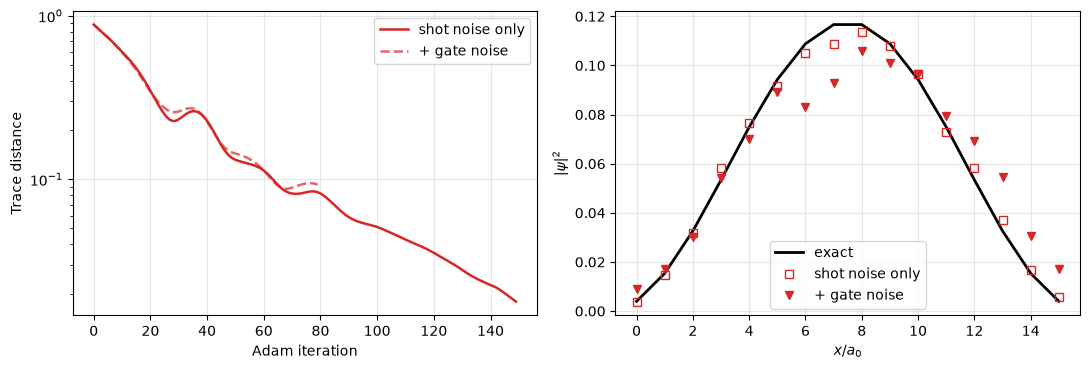

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].semilogy([h[2] for h in runs['SD']['history']], color='#d62728', lw=1.8,
               label='shot noise only')
ax[0].semilogy([h[2] for h in noisy['history']], '--', color='#d62728', lw=1.8,
               alpha=.7, label='+ gate noise')
ax[0].set_xlabel('Adam iteration'); ax[0].set_ylabel('Trace distance')
ax[0].grid(alpha=.3); ax[0].legend()

ax[1].plot(x, np.abs(prob.ground)**2, 'k-', lw=2, label='exact')
ax[1].plot(x, runs['SD']['rho'], 's', color='#d62728', mfc='none', label='shot noise only')
ax[1].plot(x, noisy['rho'], 'v', color='#d62728', label='+ gate noise')
ax[1].set_xlabel(r'$x/a_0$'); ax[1].set_ylabel(r'$|\psi|^2$')
ax[1].grid(alpha=.3); ax[1].legend()
plt.tight_layout(); plt.show()

### **Production Run**

The paper trains $N=32$ at depth 4 for 300 iterations with $2^{20}$ shots; those runs are archived under `paper/data/`.

In [16]:
import json, os
D = os.path.join('paper', 'data', 'prod')

meta = json.load(open(f'{D}/r_1d_N32_meta.json'))
print(meta['label'])
print('settings :', {k: meta['args'][k] for k in
                     ('n', 'depth', 'shots', 'maxiter', 'optimizer', 'seed', 'stages')})
print('terminal :', {k: round(v['trace'], 4) for k, v in meta['terminal'].items()})
print('wall time:', {k: f'{v/60:.0f} min' for k, v in meta['time_s'].items()})

1D box N=32, u0=0.0 eV
settings : {'n': 5, 'depth': 4, 'shots': 1048576, 'maxiter': 300, 'optimizer': 'Adam', 'seed': 111, 'stages': '300:1048576'}
terminal : {'classical': 0.001, 'SD': 0.0097, 'FD': 0.024}
wall time: {'classical': '0 min', 'SD': '141 min', 'FD': '56 min'}


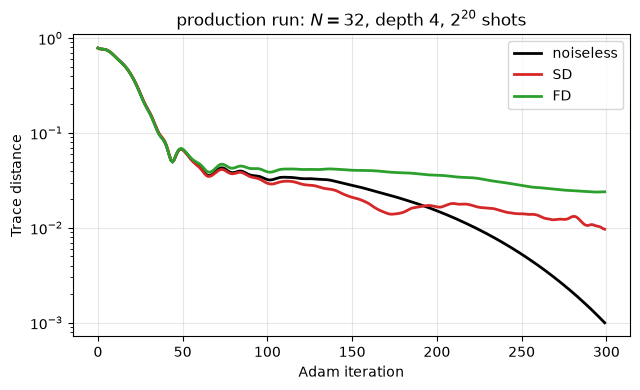

In [17]:
plt.figure(figsize=(6.5, 4))
for m, c, lab in [('classical', 'k', 'noiseless'), ('SD', '#d62728', 'SD'),
                  ('FD', '#2ca02c', 'FD')]:
    h = np.loadtxt(f'{D}/r_1d_N32_history_{m}.csv', delimiter=',', skiprows=1)
    plt.semilogy(h[:, 2], color=c, lw=2, label=lab)
plt.xlabel('Adam iteration'); plt.ylabel('Trace distance')
plt.grid(alpha=.3); plt.legend(); plt.title(r'production run: $N=32$, depth 4, $2^{20}$ shots')
plt.tight_layout(); plt.show()